# 거북목(FHP) 개선 운동 RCT 분석 — 최소 셀 버전

**AI 생성 운동(1군) vs. 표준 임상 운동(2군)** · 2(군)×2(시점) 혼합설계
주요 결과변수 **CVA(머리척추각)** · 보조 결과변수 **경부 6방향 ROM**

이 노트북은 위에서 아래로 **셀 3개만 순서대로 실행**(메뉴 ▸ 런타임 ▸ 모두 실행)하면 됩니다.
1. **설정 · 데이터** — 라이브러리/스타일, 드라이브 마운트, `input/*.xlsx` 자동 탐색·정제
2. **통계 분석 · 표** — 2×2 혼합 ANOVA(자기검증) + 효과크기 + 표1~4(+Excel 저장)
3. **그림 · 결과 요약** — 그림1~5(300dpi PNG·PDF) + 국·영문 결과 서술

결과물은 실행할 때마다 `output/run_YYYYMMDD_HHMMSS/` 폴더에 새로 저장됩니다.
그림·표는 학술지(영문) 스타일로 생성됩니다.

> ⚠️ **작성 전 확인:** 아래 CONFIG의 `GROUP_EN`(엑셀 그룹 1/2 → 군 이름) 매핑이 실제 무작위배정과 일치하는지 확인하세요. 통계량은 라벨과 무관하며, 해석만 이 매핑을 따릅니다.

In [8]:
# [1] 환경 설정 · 데이터 로드/정제  ───────────────────────────────

import sys, os, subprocess, glob, datetime, warnings
warnings.filterwarnings("ignore")
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable,"-m","pip","install","-q","pingouin"], check=False)
    try:
        from google.colab import drive; drive.mount('/content/drive')
    except Exception as e: print("drive mount skipped:", e)

import numpy as np, pandas as pd
from scipy import stats
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
try: import pingouin as pg; HAS_PINGOUIN=True
except Exception: HAS_PINGOUIN=False

# ---- Nature/Science-like style: English sans-serif, despined, no grid ----
mpl.rcParams.update({
    "figure.dpi":120, "savefig.dpi":300, "savefig.bbox":"tight",
    "font.family":"sans-serif", "font.sans-serif":["Arial","Helvetica","DejaVu Sans"],
    "mathtext.fontset":"dejavusans", "axes.unicode_minus":False,
    "font.size":10, "axes.titlesize":11, "axes.labelsize":10,
    "axes.titleweight":"bold", "axes.labelweight":"normal",
    "axes.linewidth":0.9, "axes.edgecolor":"#2b2b2b",
    "axes.spines.top":False, "axes.spines.right":False,
    "xtick.direction":"out", "ytick.direction":"out",
    "xtick.major.width":0.9, "ytick.major.width":0.9,
    "legend.frameon":False, "legend.fontsize":9,
    "axes.grid":False, "figure.facecolor":"white", "savefig.facecolor":"white",
})
np.random.seed(7)
print("Colab:", IN_COLAB, "| pingouin:", HAS_PINGOUIN, "| matplotlib", mpl.__version__)

CANDIDATES = [
    "/content/drive/MyDrive/완석_구글자료/경운대 자료/물리치료학과 자료/학술대회/2026_김서윤",
    "/Users/y3korea/Library/CloudStorage/GoogleDrive-y3korea@gmail.com/내 드라이브/완석_구글자료/경운대 자료/물리치료학과 자료/학술대회/2026_김서윤",
    os.getcwd(),
]
BASE_DIR = next((p for p in CANDIDATES if os.path.isdir(os.path.join(p,"input"))), os.getcwd())
INPUT_DIR = os.path.join(BASE_DIR,"input")
assert os.path.isdir(INPUT_DIR), "input/ not found — set BASE_DIR manually"
print("BASE_DIR:", BASE_DIR)

# ⚠️ EDIT to match the true randomisation:
GROUP_EN = {1:"AI-generated", 2:"Conventional"}      # used in ALL figures & tables
GROUP_KO = {1:"AI생성운동군(실험군)", 2:"표준임상운동군(대조군)"}  # used in Korean summary only
COLORS   = {1:"#0173B2", 2:"#D55E00"}                 # colourblind-safe (blue / vermillion)

ALPHA=0.05; SURVEY_YEAR=2026; PRIMARY="CVA"
OUTCOMES = {  # label:(pre,post)
 "CVA":("CVA_pre","CVA_post"), "Flexion":("flex_pre","flex_post"),
 "Extension":("ext_pre","ext_post"), "LatFlex_R":("latflexR_pre","latflexR_post"),
 "LatFlex_L":("latflexL_pre","latflexL_post"), "Rotation_R":("rotR_pre","rotR_post"),
 "Rotation_L":("rotL_pre","rotL_post"),
}
OUTCOME_LABELS = {  # pretty axis titles (English, with unit)
 "CVA":"Craniovertebral angle (°)","Flexion":"Flexion (°)","Extension":"Extension (°)",
 "LatFlex_R":"Lateral flexion, R (°)","LatFlex_L":"Lateral flexion, L (°)",
 "Rotation_R":"Rotation, R (°)","Rotation_L":"Rotation, L (°)",
}
SHORT = {"CVA":"CVA","Flexion":"Flex","Extension":"Ext","LatFlex_R":"LFlex-R",
         "LatFlex_L":"LFlex-L","Rotation_R":"Rot-R","Rotation_L":"Rot-L"}
GROUPS=[1,2]
print("Groups:", {g:GROUP_EN[g] for g in GROUPS})

RUN_ID = datetime.datetime.now().strftime("run_%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(BASE_DIR,"output",RUN_ID)
FIG_DIR=os.path.join(RUN_DIR,"figures"); TAB_DIR=os.path.join(RUN_DIR,"tables")
for d in (RUN_DIR,FIG_DIR,TAB_DIR): os.makedirs(d,exist_ok=True)
from IPython.display import display, Markdown, HTML

def tci(x):  # 95% CI half-width of the mean (t-based)
    x=pd.to_numeric(pd.Series(x),errors="coerce").dropna(); n=len(x)
    return float(stats.t.ppf(.975,n-1)*x.std(ddof=1)/np.sqrt(n)) if n>1 else np.nan
def star(p): return "***" if p<.001 else ("**" if p<.01 else ("*" if p<.05 else "ns"))

def show_table(dfx, caption, name, sig_cols=()):
    # display styled table inline + save CSV & HTML
    try:
        sty=(dfx.style.set_caption(caption)
             .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","12px"),("text-align","left"),("padding","4px")]},
                                {"selector":"th","props":[("background-color","#1f3b57"),("color","white"),("font-weight","bold")]} ]))
        def hl(v):
            try: return "background-color:#fde2e2;font-weight:bold" if float(v)<ALPHA else ""
            except: return ""
        for c in sig_cols:
            if c in dfx.columns: sty=sty.applymap(hl, subset=[c])
        display(sty)
        with open(os.path.join(TAB_DIR,name.replace(".csv",".html")),"w",encoding="utf-8") as f: f.write(sty.to_html())
    except Exception as e:
        display(dfx); print("(style skipped:",e,")")
    dfx.to_csv(os.path.join(TAB_DIR,name), encoding="utf-8-sig")
    return dfx

def finalize_fig(fig, name, title=None):
    try: fig.tight_layout()
    except Exception: pass
    if title: fig.suptitle(title, fontsize=12.5, fontweight="bold", y=1.02)
    fig.savefig(os.path.join(FIG_DIR,name+".png"), bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR,name+".pdf"), bbox_inches="tight")
    PDF_ALL.savefig(fig, bbox_inches="tight")
    plt.show()
    print("saved:", f"figures/{name}.png / .pdf")

def panel(ax, letter):
    ax.text(-0.16, 1.06, letter, transform=ax.transAxes, fontsize=13, fontweight="bold", va="top", ha="right")
print("output:", RUN_DIR)

xlsx=[p for p in sorted(glob.glob(os.path.join(INPUT_DIR,"*.xlsx"))) if not os.path.basename(p).startswith("~$")][0]
raw=pd.read_excel(xlsx,sheet_name=0,header=None)
COLS=["group","name","sid","birth","sex","VAS","height","weight","phone","symptom",
 "flex_pre","ext_pre","latflexR_pre","latflexL_pre","rotR_pre","rotL_pre",
 "flex_post","ext_post","latflexR_post","latflexL_post","rotR_post","rotL_post","CVA_pre","CVA_post"]
df=raw.iloc[2:,:24].copy(); df.columns=COLS
df=df[df["name"].notna() & (df["name"].astype(str).str.strip()!="") & (~df["group"].astype(str).str.contains("평균"))].reset_index(drop=True)
for c in [x for p in OUTCOMES.values() for x in p]+["group","sex","VAS","height","weight","birth"]:
    df[c]=pd.to_numeric(df[c],errors="coerce")
df=df[df["group"].isin(GROUPS)].copy(); df["group"]=df["group"].astype(int)
def parse_phone(v):
    if pd.isna(v): return np.nan
    s=str(v).replace("시","").replace("간","").strip()
    for sep in["~","-","–"]:
        if sep in s:
            try: a,b=s.split(sep)[:2]; return (float(a)+float(b))/2
            except: return np.nan
    try: return float(s)
    except: return np.nan
df["phone_h"]=df["phone"].apply(parse_phone); df["age"]=SURVEY_YEAR-df["birth"]
df["arm"]=df["group"].map(GROUP_EN)
out_cols=[x for p in OUTCOMES.values() for x in p]
complete=df[df[out_cols].notna().all(axis=1)].copy()
print(f"Randomised n={len(df)} | complete-case n={len(complete)} (by group {complete.groupby('group').size().to_dict()})")
print("fully-missing outcomes:", df[df[out_cols].isna().all(axis=1)]["name"].tolist())
df.to_csv(os.path.join(TAB_DIR,"00_cleaned_data.csv"),index=False,encoding="utf-8-sig")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True | pingouin: True | matplotlib 3.10.0
BASE_DIR: /content/drive/MyDrive/완석_구글자료/경운대 자료/물리치료학과 자료/학술대회/2026_김서윤
Groups: {1: 'AI-generated', 2: 'Conventional'}
output: /content/drive/MyDrive/완석_구글자료/경운대 자료/물리치료학과 자료/학술대회/2026_김서윤/output/run_20260531_124346
Randomised n=40 | complete-case n=34 (by group {1: 17, 2: 17})
fully-missing outcomes: ['김주하', '도규원', '우상범', '이승우', '한지민', '홍은혜']


In [9]:
# [2] 통계 분석 · 표 1~4 (혼합 ANOVA · 효과크기 · Excel 저장)  ──────────

def mixed_anova_2x2(d,pre,post):
    d=d[["group",pre,post]].dropna().copy(); g=sorted(d["group"].unique()); assert len(g)==2
    n=len(d); a=b=2; allobs=np.r_[d[pre].values,d[post].values]; GM=allobs.mean()
    SS_tot=((allobs-GM)**2).sum(); ni={k:int((d["group"]==k).sum()) for k in g}
    subj=(d[pre].values+d[post].values)/2; SS_bs=b*((subj-GM)**2).sum()
    gm={k:subj[d["group"].values==k].mean() for k in g}
    SS_g=sum(b*ni[k]*(gm[k]-GM)**2 for k in g); SS_swg=SS_bs-SS_g
    tm={"pre":d[pre].mean(),"post":d[post].mean()}; SS_t=sum(n*(tm[s]-GM)**2 for s in tm)
    cell={(k,s):d[d["group"]==k][pre if s=="pre" else post].mean() for k in g for s in["pre","post"]}
    SS_c=sum(ni[k]*(cell[(k,s)]-GM)**2 for k in g for s in["pre","post"])
    SS_i=SS_c-SS_g-SS_t; SS_ew=(SS_tot-SS_bs)-SS_t-SS_i
    dfg=a-1; dfswg=n-a; dft=b-1; dfi=(a-1)*(b-1); dfew=(n-a)*(b-1)
    MSe_b=SS_swg/dfswg; MSe_w=SS_ew/dfew
    Fg=(SS_g/dfg)/MSe_b; Ft=(SS_t/dft)/MSe_w; Fi=(SS_i/dfi)/MSe_w
    pe=lambda ss,sse: ss/(ss+sse)
    return {"n":n,"ni":ni,"cell":cell,
        "group":(Fg,stats.f.sf(Fg,dfg,dfswg),pe(SS_g,SS_swg),dfg,dfswg),
        "time":(Ft,stats.f.sf(Ft,dft,dfew),pe(SS_t,SS_ew),dft,dfew),
        "interaction":(Fi,stats.f.sf(Fi,dfi,dfew),pe(SS_i,SS_ew),dfi,dfew)}

ANOVA={}; checks={}
for lab,(pre,post) in OUTCOMES.items():
    r=mixed_anova_2x2(df,pre,post); ANOVA[lab]=r
    d=df[["group",pre,post]].dropna(); ch=d[post]-d[pre]; g=sorted(d.group.unique())
    t_ch=stats.ttest_ind(ch[d.group==g[0]],ch[d.group==g[1]]).statistic
    sm=(d[pre].values+d[post].values)/2; t_sm=stats.ttest_ind(sm[d.group.values==g[0]],sm[d.group.values==g[1]]).statistic
    checks[lab]=(np.isclose(r["interaction"][0],t_ch**2), np.isclose(r["group"][0],t_sm**2))
print("self-validation (interaction F=t_change² , group F=t_subjmean²):", "ALL PASS" if all(all(v) for v in checks.values()) else checks)
if HAS_PINGOUIN:
    print("pingouin cross-check (interaction):")
    dfu = df.reset_index(drop=True); dfu["uid"] = dfu.index   # 동명이인('이준석') 대비: 이름 대신 고유 ID를 subject로
    try:
        for lab,(pre,post) in OUTCOMES.items():
            s=dfu[["uid","group",pre,post]].dropna().melt(id_vars=["uid","group"],value_vars=[pre,post],var_name="time")
            a=pg.mixed_anova(s,dv="value",within="time",between="group",subject="uid")
            i=a[a.Source=="Interaction"].iloc[0]
            pc=next((c for c in ("p-unc","p_unc","p") if c in a.columns), None)   # pingouin 버전별: p-unc / p_unc
            ec="np2" if "np2" in a.columns else None
            pv=f"{i[pc]:.4f}" if pc else "n/a"; ev=f"{i[ec]:.3f}" if ec else "n/a"
            print(f"  {lab:11} pg F={i['F']:.3f} p={pv} np2={ev} | manual F={ANOVA[lab]['interaction'][0]:.3f}")
    except Exception as e:
        print("  (pingouin 교차검증 생략:", type(e).__name__, str(e)[:60], "— 수동 ANOVA 자기검증으로 충분)")

WITHIN={}; BETWEEN={}
for lab,(pre,post) in OUTCOMES.items():
    WITHIN[lab]={}
    d=df[["group",pre,post]].dropna()
    for gg in GROUPS:
        s=d[d.group==gg]; diff=s[post]-s[pre]; n=len(s)
        tp,pp=stats.ttest_rel(s[post],s[pre]); dz=diff.mean()/diff.std(ddof=1)
        se_dz=np.sqrt(1/n+dz**2/(2*n)); tcrit=stats.t.ppf(.975,n-1)
        WITHIN[lab][gg]=dict(delta=diff.mean(), ci=tci(diff), p=pp, dz=dz, dz_ci=tcrit*se_dz, n=n)
    g=sorted(d.group.unique()); c1=(d[post]-d[pre])[d.group==g[0]]; c2=(d[post]-d[pre])[d.group==g[1]]
    n1,n2=len(c1),len(c2); sp=np.sqrt(((n1-1)*c1.var(ddof=1)+(n2-1)*c2.var(ddof=1))/(n1+n2-2))
    se=sp*np.sqrt(1/n1+1/n2); diffm=c1.mean()-c2.mean(); tcrit=stats.t.ppf(.975,n1+n2-2)
    tt,pb=stats.ttest_ind(c1,c2); dcoh=diffm/sp if sp>0 else np.nan
    BETWEEN[lab]=dict(diff=diffm, ci=tcrit*se, t=tt, p=pb, d=dcoh)
print("within/between effect sizes computed for", len(OUTCOMES), "outcomes")

def msd(x): x=pd.to_numeric(pd.Series(x),errors="coerce").dropna(); return f"{x.mean():.2f} ± {x.std(ddof=1):.2f}"
# ---- Table 1: baseline characteristics + homogeneity tests ----
rows=[]
for v,lab in [("age","Age (years)"),("height","Height (cm)"),("weight","Weight (kg)"),("VAS","VAS (0–10)"),("phone_h","Smartphone use (h/day)")]:
    x1=df[df.group==1][v]; x2=df[df.group==2][v]
    sw=(stats.shapiro(x1.dropna()).pvalue>ALPHA) and (stats.shapiro(x2.dropna()).pvalue>ALPHA)
    if sw: st,p=stats.ttest_ind(x1.dropna(),x2.dropna()); test="t"
    else: st,p=stats.mannwhitneyu(x1.dropna(),x2.dropna()); test="MWU"
    rows.append([lab, msd(x1), msd(x2), f"{test}", f"{p:.3f}"])
sex=pd.crosstab(df.group,df.sex); chi2,pchi,_,_=stats.chi2_contingency(sex)
rows.insert(0,["Sex (M/F)", f"{int((df[df.group==1].sex==1).sum())}/{int((df[df.group==1].sex==2).sum())}",
               f"{int((df[df.group==2].sex==1).sum())}/{int((df[df.group==2].sex==2).sum())}","χ²",f"{pchi:.3f}"])
table1=pd.DataFrame(rows,columns=["Characteristic",f"{GROUP_EN[1]} (n={int((df.group==1).sum())})",
                                  f"{GROUP_EN[2]} (n={int((df.group==2).sum())})","Test","p"]).set_index("Characteristic")
show_table(table1,"Table 1. Baseline characteristics (randomised sample)","T1_baseline.csv",sig_cols=["p"])

# ---- Table 2: outcomes pre/post by group + within-group change & paired p ----
rows=[]
for lab,(pre,post) in OUTCOMES.items():
    for gg in GROUPS:
        s=df[df.group==gg][[pre,post]].dropna(); w=WITHIN[lab][gg]
        rows.append([OUTCOME_LABELS[lab], GROUP_EN[gg], len(s),
                     f"{s[pre].mean():.2f} ± {s[pre].std(ddof=1):.2f}",
                     f"{s[post].mean():.2f} ± {s[post].std(ddof=1):.2f}",
                     f"{w['delta']:+.2f}", f"{w['dz']:+.2f}", f"{w['p']:.3f}", star(w['p'])])
table2=pd.DataFrame(rows,columns=["Outcome","Arm","n","Pre (M±SD)","Post (M±SD)","Δ","Cohen's dz","p(paired)","sig"]).set_index(["Outcome","Arm"])
show_table(table2,"Table 2. Pre/post values and within-arm change (paired t-test)","T2_descriptives.csv",sig_cols=["p(paired)"])

# ---- Table 3: mixed ANOVA (Time, Group, Group×Time) ----
def npint(e): return "large" if e>=.14 else ("medium" if e>=.06 else ("small" if e>=.01 else "—"))
rows=[]
for lab,(pre,post) in OUTCOMES.items():
    r=ANOVA[lab]
    for eff,nm in [("time","Time"),("group","Group"),("interaction","Group × Time")]:
        F,p,e,d1,d2=r[eff]
        rows.append([OUTCOME_LABELS[lab],nm,f"{d1},{d2}",f"{F:.2f}",f"{p:.3f}",star(p),f"{e:.3f}",npint(e)])
table3=pd.DataFrame(rows,columns=["Outcome","Effect","df","F","p","sig","partial η²","ES"]).set_index(["Outcome","Effect"])
show_table(table3,"Table 3. Mixed-design (2×2) repeated-measures ANOVA","T3_mixed_anova.csv",sig_cols=["p"])

# ---- Table 4: between-arm treatment effect (difference in change) ----
m=len(OUTCOMES); bonf=ALPHA/m; rows=[]
for lab in OUTCOMES:
    b=BETWEEN[lab]
    rows.append([OUTCOME_LABELS[lab], f"{b['diff']:+.2f}", f"[{b['diff']-b['ci']:+.2f}, {b['diff']+b['ci']:+.2f}]",
                 f"{b['t']:.2f}", f"{b['p']:.3f}", f"{b['d']:+.2f}", ("yes" if b['p']<bonf else "no")])
table4=pd.DataFrame(rows,columns=["Outcome",f"ΔΔ ({GROUP_EN[1]}−{GROUP_EN[2]})","95% CI","t","p","Cohen's d",f"sig@Bonf(α={bonf:.3f})"]).set_index("Outcome")
show_table(table4,"Table 4. Between-arm difference in pre→post change (independent t-test)","T4_between.csv",sig_cols=["p"])
# combined workbook
try:
    with pd.ExcelWriter(os.path.join(TAB_DIR,"all_tables.xlsx")) as xl:
        table1.to_excel(xl,"T1_baseline"); table2.to_excel(xl,"T2_descriptives")
        table3.to_excel(xl,"T3_anova"); table4.to_excel(xl,"T4_between")
    print("saved: tables/all_tables.xlsx")
except Exception as e: print("xlsx skip:",e)

self-validation (interaction F=t_change² , group F=t_subjmean²): ALL PASS
pingouin cross-check (interaction):
  CVA         pg F=1.407 p=0.2442 np2=0.042 | manual F=1.407
  Flexion     pg F=0.143 p=0.7076 np2=0.004 | manual F=0.143
  Extension   pg F=0.481 p=0.4930 np2=0.015 | manual F=0.481
  LatFlex_R   pg F=0.117 p=0.7346 np2=0.004 | manual F=0.117
  LatFlex_L   pg F=0.005 p=0.9436 np2=0.000 | manual F=0.005
  Rotation_R  pg F=2.842 p=0.1015 np2=0.082 | manual F=2.842
  Rotation_L  pg F=1.820 p=0.1868 np2=0.054 | manual F=1.820
within/between effect sizes computed for 7 outcomes


,AI-generated (n=20),Conventional (n=20),Test,p
Characteristic,,,,
Sex (M/F),14/6,15/5,χ²,1.000
Age (years),20.00 ± 1.26,20.30 ± 1.56,MWU,0.626
Height (cm),171.70 ± 8.14,172.55 ± 8.83,t,0.753
Weight (kg),79.65 ± 19.27,78.20 ± 16.94,t,0.802
VAS (0–10),1.60 ± 1.14,1.75 ± 1.41,MWU,0.822
Smartphone use (h/day),4.97 ± 2.24,4.75 ± 1.43,MWU,0.792


,ΔΔ (AI-generated−Conventional),95% CI,t,p,Cohen's d,sig@Bonf(α=0.007)
Outcome,,,,,,
Craniovertebral angle (°),+2.55,"[-1.83, +6.93]",1.19,0.244,+0.41,no
Flexion (°),-1.69,"[-10.78, +7.40]",-0.38,0.708,-0.13,no
Extension (°),+3.35,"[-6.49, +13.20]",0.69,0.493,+0.24,no
"Lateral flexion, R (°)",+0.84,"[-4.17, +5.85]",0.34,0.735,+0.12,no
"Lateral flexion, L (°)",-0.28,"[-8.35, +7.79]",-0.07,0.944,-0.02,no
"Rotation, R (°)",-7.16,"[-15.81, +1.49]",-1.69,0.102,-0.58,no
"Rotation, L (°)",-5.09,"[-12.77, +2.59]",-1.35,0.187,-0.46,no


saved: tables/all_tables.xlsx


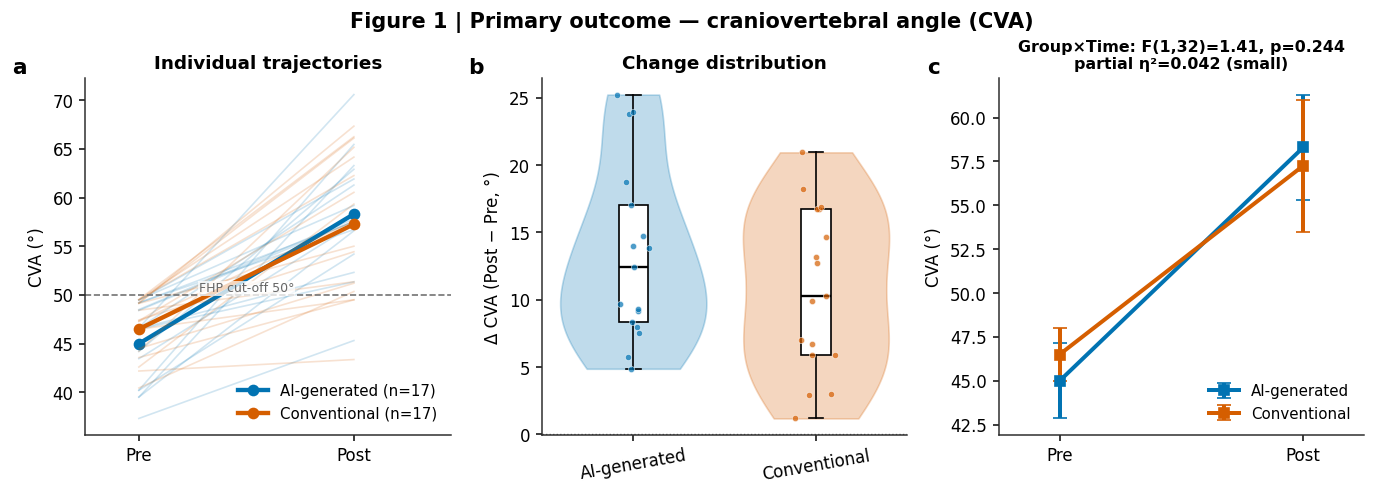

saved: figures/Fig1_CVA_primary.png / .pdf


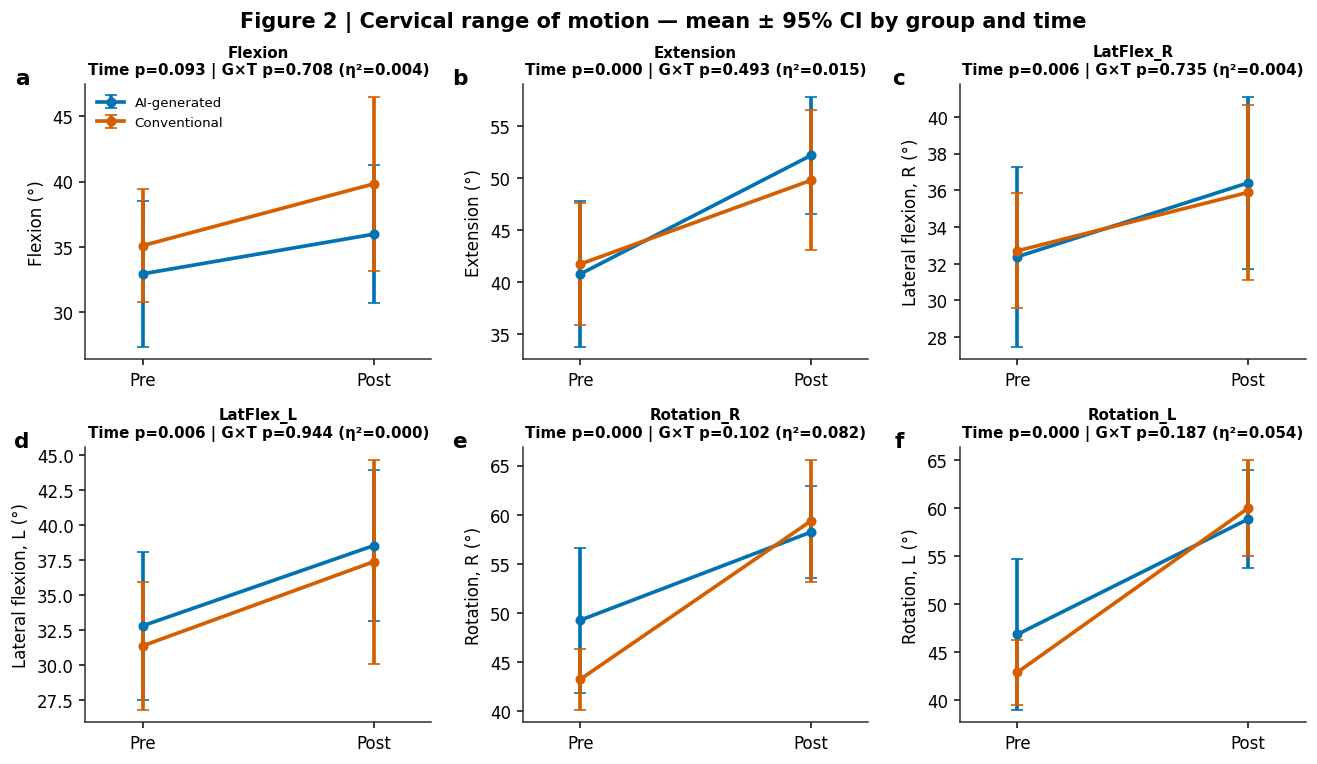

saved: figures/Fig2_ROM_grid.png / .pdf


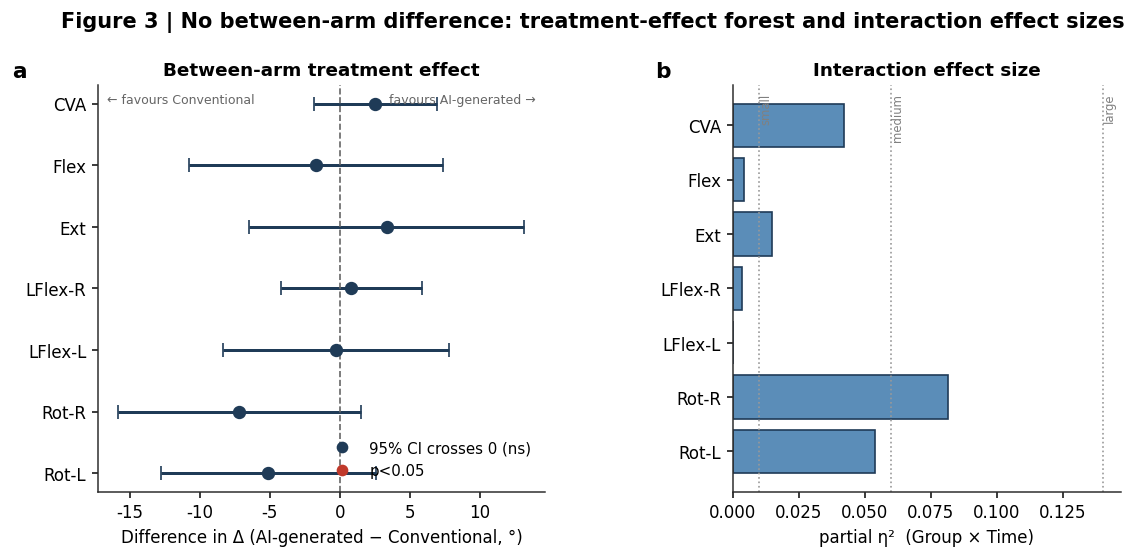

saved: figures/Fig3_forest_between.png / .pdf


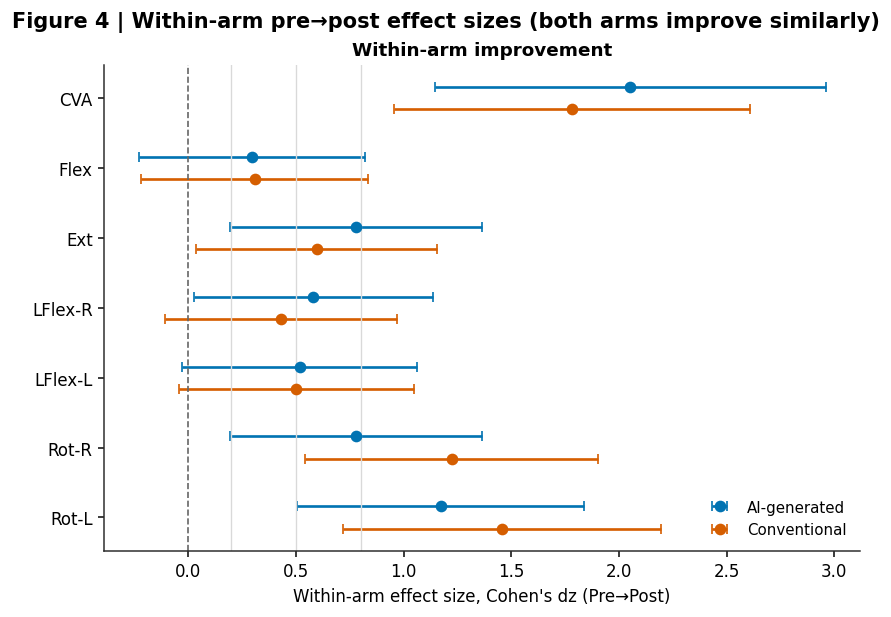

saved: figures/Fig4_within_dz.png / .pdf


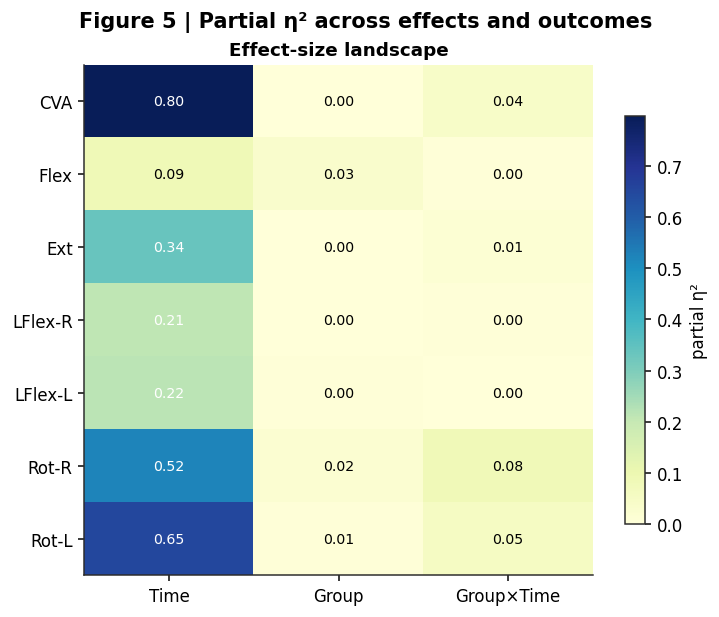

saved: figures/Fig5_effectsize_heatmap.png / .pdf
saved: figures/all_figures.pdf


### Results (English, publication style)

Of 40 randomised participants, 34 (n=17 AI-generated, n=17 Conventional) had complete pre/post data and were analysed; 6 had no outcome measurements and could not be imputed.

Groups were comparable at baseline on all variables (Table 1; all p>0.05), indicating successful randomisation.

A 2 (group) × 2 (time) mixed ANOVA revealed a significant main effect of time for 6 of 7 outcomes (CVA: F(1,32)=125.41, p<0.001, partial η²=0.80), reflecting improvement in both arms.

Critically, the group × time interaction was non-significant for every outcome (CVA: F=1.41, p=0.244, partial η²=0.042; all other outcomes p>0.10), and all between-arm differences in change had 95% CIs spanning zero (Table 4, Fig. 3).

Thus the null hypothesis of no between-arm difference was not rejected: the AI-generated exercise programme produced improvements in CVA and cervical ROM comparable to the conventional clinical programme.

### 요약 (Korean)

무작위배정 40명 중 완전자료 34명 분석. 기저 동질성 확보(모든 변수 p>0.05). 시점 주효과는 6/7 변수에서 유의(양 군 호전). 군×시점 상호작용은 모든 변수에서 비유의 → 두 운동의 효과 차이 없음(AI 운동이 표준 임상운동과 동등).


saved: REPORT.md
RUN_DIR: /content/drive/MyDrive/완석_구글자료/경운대 자료/물리치료학과 자료/학술대회/2026_김서윤/output/run_20260531_124346 

   REPORT.md
   figures/Fig1_CVA_primary.pdf
   figures/Fig1_CVA_primary.png
   figures/Fig2_ROM_grid.pdf
   figures/Fig2_ROM_grid.png
   figures/Fig3_forest_between.pdf
   figures/Fig3_forest_between.png
   figures/Fig4_within_dz.pdf
   figures/Fig4_within_dz.png
   figures/Fig5_effectsize_heatmap.pdf
   figures/Fig5_effectsize_heatmap.png
   figures/all_figures.pdf
   tables/00_cleaned_data.csv
   tables/T1_baseline.csv
   tables/T1_baseline.html
   tables/T2_descriptives.csv
   tables/T2_descriptives.html
   tables/T3_mixed_anova.csv
   tables/T3_mixed_anova.html
   tables/T4_between.csv
   tables/T4_between.html
   tables/all_tables.xlsx

[reminder] Figures/tables use English labels with legends. Confirm GROUP_EN mapping before the write-up.


In [10]:
PDF_ALL = PdfPages(os.path.join(FIG_DIR,"all_figures.pdf"))

# [3] 그림 1~5 · 결과 요약 · 산출물 목록  ─────────────────────────

pre,post=OUTCOMES[PRIMARY]
fig,(axA,axB,axC)=plt.subplots(1,3,figsize=(11.5,4.0))
# (a) individual trajectories
for gg in GROUPS:
    s=df[df.group==gg][[pre,post]].dropna()
    for _,r in s.iterrows(): axA.plot([0,1],[r[pre],r[post]],color=COLORS[gg],alpha=0.18,lw=1)
    m=[s[pre].mean(),s[post].mean()]; axA.plot([0,1],m,color=COLORS[gg],lw=2.6,marker="o",ms=6,label=f"{GROUP_EN[gg]} (n={len(s)})")
axA.axhline(50,ls="--",color="0.45",lw=1)
axA.text(0.5,50,"FHP cut-off 50°",va="bottom",ha="center",fontsize=7.5,color="0.4",
         bbox=dict(fc="white",ec="none",alpha=0.75,pad=0.6))
axA.set_xticks([0,1]); axA.set_xticklabels(["Pre","Post"]); axA.set_xlim(-0.25,1.45)
axA.set_ylabel("CVA (°)"); axA.set_title("Individual trajectories"); axA.legend(loc="lower right"); panel(axA,"a")
# (b) raincloud of change
data=[ (df[df.group==gg][post]-df[df.group==gg][pre]).dropna().values for gg in GROUPS]
parts=axB.violinplot(data,positions=[0,1],showextrema=False,widths=0.8)
for i,pc in enumerate(parts['bodies']): pc.set_facecolor(COLORS[GROUPS[i]]); pc.set_alpha(0.25); pc.set_edgecolor(COLORS[GROUPS[i]])
bp=axB.boxplot(data,positions=[0,1],widths=0.16,patch_artist=True,showfliers=False,
   medianprops=dict(color="k",lw=1.4),boxprops=dict(facecolor="white",lw=1),whiskerprops=dict(lw=1),capprops=dict(lw=1))
for i,gg in enumerate(GROUPS):
    x=np.random.normal(i,0.05,len(data[i])); axB.scatter(x,data[i],s=14,color=COLORS[gg],alpha=0.7,edgecolor="white",lw=0.4,zorder=3)
axB.axhline(0,color="0.4",lw=0.8,ls=":"); axB.set_xticks([0,1]); axB.set_xticklabels([GROUP_EN[g] for g in GROUPS],rotation=10)
axB.set_ylabel("Δ CVA (Post − Pre, °)"); axB.set_title("Change distribution"); panel(axB,"b")
# (c) mean +/- 95% CI interaction
for gg in GROUPS:
    s=df[df.group==gg][[pre,post]].dropna(); m=[s[pre].mean(),s[post].mean()]; ci=[tci(s[pre]),tci(s[post])]
    axC.errorbar([0,1],m,yerr=ci,color=COLORS[gg],lw=2.4,marker="s",ms=6,capsize=4,label=GROUP_EN[gg])
F,p,e,d1,d2=ANOVA[PRIMARY]["interaction"]
axC.set_xticks([0,1]); axC.set_xticklabels(["Pre","Post"]); axC.set_xlim(-0.25,1.25); axC.set_ylabel("CVA (°)")
axC.set_title(f"Group×Time: F({d1},{d2})={F:.2f}, p={p:.3f}\npartial η²={e:.3f} ({npint(e)})",fontsize=9.5)
axC.legend(loc="lower right"); panel(axC,"c")
finalize_fig(fig,"Fig1_CVA_primary","Figure 1 | Primary outcome — craniovertebral angle (CVA)")

roms=[k for k in OUTCOMES if k!="CVA"]
fig,axes=plt.subplots(2,3,figsize=(11,6.2)); axes=axes.ravel()
for i,lab in enumerate(roms):
    ax=axes[i]; pre,post=OUTCOMES[lab]
    for gg in GROUPS:
        s=df[df.group==gg][[pre,post]].dropna(); m=[s[pre].mean(),s[post].mean()]; ci=[tci(s[pre]),tci(s[post])]
        ax.errorbar([0,1],m,yerr=ci,color=COLORS[gg],lw=2.2,marker="o",ms=5,capsize=3.5,label=GROUP_EN[gg])
    Ft,pt,et,_,_=ANOVA[lab]["time"]; Fi,pi,ei,_,_=ANOVA[lab]["interaction"]
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pre","Post"]); ax.set_xlim(-0.25,1.25)
    ax.set_ylabel(OUTCOME_LABELS[lab]); ax.set_title(f"{lab}\nTime p={pt:.3f} | G×T p={pi:.3f} (η²={ei:.3f})",fontsize=9)
    panel(ax,"abcdef"[i])
axes[0].legend(loc="upper left",fontsize=8)
finalize_fig(fig,"Fig2_ROM_grid","Figure 2 | Cervical range of motion — mean ± 95% CI by group and time")

labs=list(OUTCOMES); y=np.arange(len(labs))[::-1]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(11,4.4),gridspec_kw=dict(wspace=0.45,width_ratios=[1.15,1]))
# (a) difference in change with 95% CI
for i,lab in enumerate(labs):
    b=BETWEEN[lab]; sigc="#C0392B" if b['p']<ALPHA else "#1f3b57"
    ax1.errorbar(b['diff'],y[i],xerr=b['ci'],fmt="o",ms=7,color=sigc,capsize=4,lw=1.8)
ax1.axvline(0,color="0.4",lw=1,ls="--"); ax1.set_yticks(y); ax1.set_yticklabels([SHORT[l] for l in labs])
ax1.set_xlabel(f"Difference in Δ ({GROUP_EN[1]} − {GROUP_EN[2]}, °)"); ax1.set_title("Between-arm treatment effect")
ax1.text(0.02,0.98,"← favours "+GROUP_EN[2],transform=ax1.transAxes,fontsize=7.5,color="0.4",va="top")
ax1.text(0.98,0.98,"favours "+GROUP_EN[1]+" →",transform=ax1.transAxes,fontsize=7.5,color="0.4",va="top",ha="right")
ax1.legend(handles=[Line2D([0],[0],marker="o",color="#1f3b57",ls="none",label="95% CI crosses 0 (ns)"),
                    Line2D([0],[0],marker="o",color="#C0392B",ls="none",label="p<0.05")],loc="lower right"); panel(ax1,"a")
# (b) Group×Time partial eta^2 with thresholds
e=[ANOVA[l]["interaction"][2] for l in labs]
ax2.barh(y,e,color="#5B8DB8",edgecolor="#1f3b57");
for thr,nm in [(0.01,"small"),(0.06,"medium"),(0.14,"large")]:
    ax2.axvline(thr,color="0.6",ls=":",lw=1); ax2.text(thr,len(labs)-0.4,nm,rotation=90,fontsize=7,va="top",color="0.5")
ax2.set_yticks(y); ax2.set_yticklabels([SHORT[l] for l in labs]); ax2.set_xlabel("partial η²  (Group × Time)")
ax2.set_title("Interaction effect size"); panel(ax2,"b")
finalize_fig(fig,"Fig3_forest_between","Figure 3 | No between-arm difference: treatment-effect forest and interaction effect sizes")

labs=list(OUTCOMES); y=np.arange(len(labs))[::-1]; off=0.16
fig,ax=plt.subplots(figsize=(7.2,5))
for k,gg in enumerate(GROUPS):
    yy=y+(off if k==0 else -off)
    dz=[WITHIN[l][gg]["dz"] for l in labs]; ci=[WITHIN[l][gg]["dz_ci"] for l in labs]
    ax.errorbar(dz,yy,xerr=ci,fmt="o",ms=6,color=COLORS[gg],capsize=3,lw=1.6,label=GROUP_EN[gg])
ax.axvline(0,color="0.4",lw=1,ls="--")
for thr in (0.2,0.5,0.8): ax.axvline(thr,color="0.85",lw=0.8)
ax.set_yticks(y); ax.set_yticklabels([SHORT[l] for l in labs]); ax.set_xlabel("Within-arm effect size, Cohen's dz (Pre→Post)")
ax.set_title("Within-arm improvement"); ax.legend(loc="lower right")
finalize_fig(fig,"Fig4_within_dz","Figure 4 | Within-arm pre→post effect sizes (both arms improve similarly)")

labs=list(OUTCOMES)
M=np.array([[ANOVA[l]["time"][2],ANOVA[l]["group"][2],ANOVA[l]["interaction"][2]] for l in labs])
fig,ax=plt.subplots(figsize=(6.2,5))
im=ax.imshow(M,aspect="auto",cmap="YlGnBu",vmin=0,vmax=max(0.2,M.max()))
ax.set_xticks(range(3)); ax.set_xticklabels(["Time","Group","Group×Time"]); ax.set_yticks(range(len(labs))); ax.set_yticklabels([SHORT[l] for l in labs])
for i in range(len(labs)):
    for j in range(3):
        ax.text(j,i,f"{M[i,j]:.2f}",ha="center",va="center",fontsize=8.5,color=("white" if M[i,j]>0.12 else "black"))
cb=fig.colorbar(im,ax=ax,shrink=0.8); cb.set_label("partial η²")
ax.set_title("Effect-size landscape");
finalize_fig(fig,"Fig5_effectsize_heatmap","Figure 5 | Partial η² across effects and outcomes")
PDF_ALL.close(); print("saved: figures/all_figures.pdf")

nsig=sum(ANOVA[l]['interaction'][1]<ALPHA for l in OUTCOMES)
nt=sum(ANOVA[l]['time'][1]<ALPHA for l in OUTCOMES)
EN=[]
EN.append(f"Of {len(df)} randomised participants, {len(complete)} (n={int((complete.group==1).sum())} {GROUP_EN[1]}, "
          f"n={int((complete.group==2).sum())} {GROUP_EN[2]}) had complete pre/post data and were analysed; "
          f"{len(df)-len(complete)} had no outcome measurements and could not be imputed.")
EN.append("Groups were comparable at baseline on all variables (Table 1; all p>0.05), indicating successful randomisation.")
EN.append(f"A 2 (group) × 2 (time) mixed ANOVA revealed a significant main effect of time for {nt} of {len(OUTCOMES)} outcomes "
          f"(CVA: F({ANOVA['CVA']['time'][3]},{ANOVA['CVA']['time'][4]})={ANOVA['CVA']['time'][0]:.2f}, p<0.001, "
          f"partial η²={ANOVA['CVA']['time'][2]:.2f}), reflecting improvement in both arms.")
if nsig==0:
    EN.append("Critically, the group × time interaction was non-significant for every outcome "
              f"(CVA: F={ANOVA['CVA']['interaction'][0]:.2f}, p={ANOVA['CVA']['interaction'][1]:.3f}, partial η²={ANOVA['CVA']['interaction'][2]:.3f}; "
              "all other outcomes p>0.10), and all between-arm differences in change had 95% CIs spanning zero (Table 4, Fig. 3).")
    EN.append("Thus the null hypothesis of no between-arm difference was not rejected: the AI-generated exercise programme produced "
              "improvements in CVA and cervical ROM comparable to the conventional clinical programme.")
else:
    EN.append(f"A significant group × time interaction was found for {nsig} outcome(s); see Tables 3–4.")
en_txt="\n\n".join(EN)
KO=(f"무작위배정 {len(df)}명 중 완전자료 {len(complete)}명 분석. 기저 동질성 확보(모든 변수 p>0.05). "
    f"시점 주효과는 {nt}/{len(OUTCOMES)} 변수에서 유의(양 군 호전). "
    + ("군×시점 상호작용은 모든 변수에서 비유의 → 두 운동의 효과 차이 없음(AI 운동이 표준 임상운동과 동등)."
       if nsig==0 else f"{nsig}개 변수에서 유의한 상호작용 관찰(표 3–4 참조).") )
display(Markdown("### Results (English, publication style)\n\n"+en_txt+"\n\n### 요약 (Korean)\n\n"+KO))
with open(os.path.join(RUN_DIR,"REPORT.md"),"w",encoding="utf-8") as f:
    f.write("# RESULTS\n\n## English\n\n"+en_txt+"\n\n## Korean\n\n"+KO+"\n")
print("\nsaved: REPORT.md")

print("RUN_DIR:",RUN_DIR,"\n")
for root,_,files in os.walk(RUN_DIR):
    for fn in sorted(files): print("  ",os.path.relpath(os.path.join(root,fn),RUN_DIR))
print("\n[reminder] Figures/tables use English labels with legends. Confirm GROUP_EN mapping before the write-up.")